<a href="https://colab.research.google.com/github/Bunkhuoch-Ann/Hybrid_image/blob/main/Hybrid_imaging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img_path1 = '/content/Screenshot 2025-09-12 at 3.44.35 PM.png'
img_path2 = '/content/Screenshot 2025-09-12 at 3.44.42 PM.png'

img1 = plt.imread(img_path1)
img2 = plt.imread(img_path2)

img1 = img1[:, :, 0]
img2 = img2[:, :, 0]

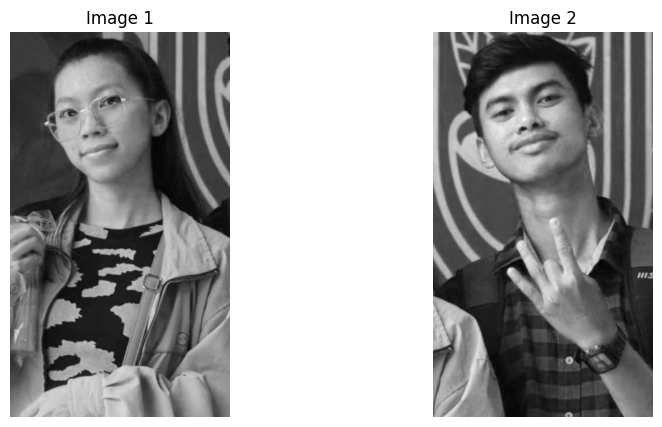

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Image 1')
axes[0].axis('off')
axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Image 2')
axes[1].axis('off')
plt.show()

In [ ]:
img1.shape, img2.shape

((728, 416), (728, 416))

In [ ]:
f_transform1 = np.fft.fft2(img1)
f_transform2 = np.fft.fft2(img2)

In [ ]:
f_transform_shifted1 = np.fft.fftshift(f_transform1)
f_transform_shifted2 = np.fft.fftshift(f_transform2)

In [ ]:
height, width = f_transform_shifted1.shape

low_pass_filter = np.ones((height, width))
high_pass_filter = np.ones((height, width))

cutoff_frequency = 50

center_y, center_x = height // 2, width // 2

for y in range(height):
    for x in range(width):
        distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        if distance > cutoff_frequency:
            low_pass_filter[y, x] = 0
        if distance < cutoff_frequency:
            high_pass_filter[y, x] = 0

In [ ]:
height1, width1 = f_transform_shifted1.shape
height2, width2 = f_transform_shifted2.shape

low_pass_filter1 = np.ones((height1, width1))
high_pass_filter1 = np.ones((height1, width1))

low_pass_filter2 = np.ones((height2, width2))
high_pass_filter2 = np.ones((height2, width2))

cutoff_frequency1 = 1
cutoff_frequency2 = 23

center_y1, center_x1 = height1 // 2, width1 // 2
center_y2, center_x2 = height2 // 2, width2 // 2

for y in range(height1):
    for x in range(width1):
        distance = np.sqrt((x - center_x1)**2 + (y - center_y1)**2)
        if distance > cutoff_frequency1:
            low_pass_filter1[y, x] = 0
        if distance < cutoff_frequency1:
            high_pass_filter1[y, x] = 0

for y in range(height2):
    for x in range(width2):
        distance = np.sqrt((x - center_x2)**2 + (y - center_y2)**2)
        if distance > cutoff_frequency2:
            low_pass_filter2[y, x] = 0
        if distance < cutoff_frequency2:
            high_pass_filter2[y, x] = 0

filtered_f_transform1 = f_transform_shifted1 * high_pass_filter1
filtered_f_transform2 = f_transform_shifted2 * low_pass_filter2

In [ ]:
filtered_f_transform_shifted_back1 = np.fft.ifftshift(filtered_f_transform1)
filtered_f_transform_shifted_back2 = np.fft.ifftshift(filtered_f_transform2)

In [ ]:
filtered_img1 = np.fft.ifft2(filtered_f_transform_shifted_back1)
filtered_img2 = np.fft.ifft2(filtered_f_transform_shifted_back2)

filtered_img1 = np.abs(filtered_img1)
filtered_img2 = np.abs(filtered_img2)

# Invert the values of filtered_img1 to make edges black and background gray
# Scale to the maximum value to ensure the background is close to white (or gray depending on the range)
filtered_img1 = np.max(filtered_img1) - filtered_img1

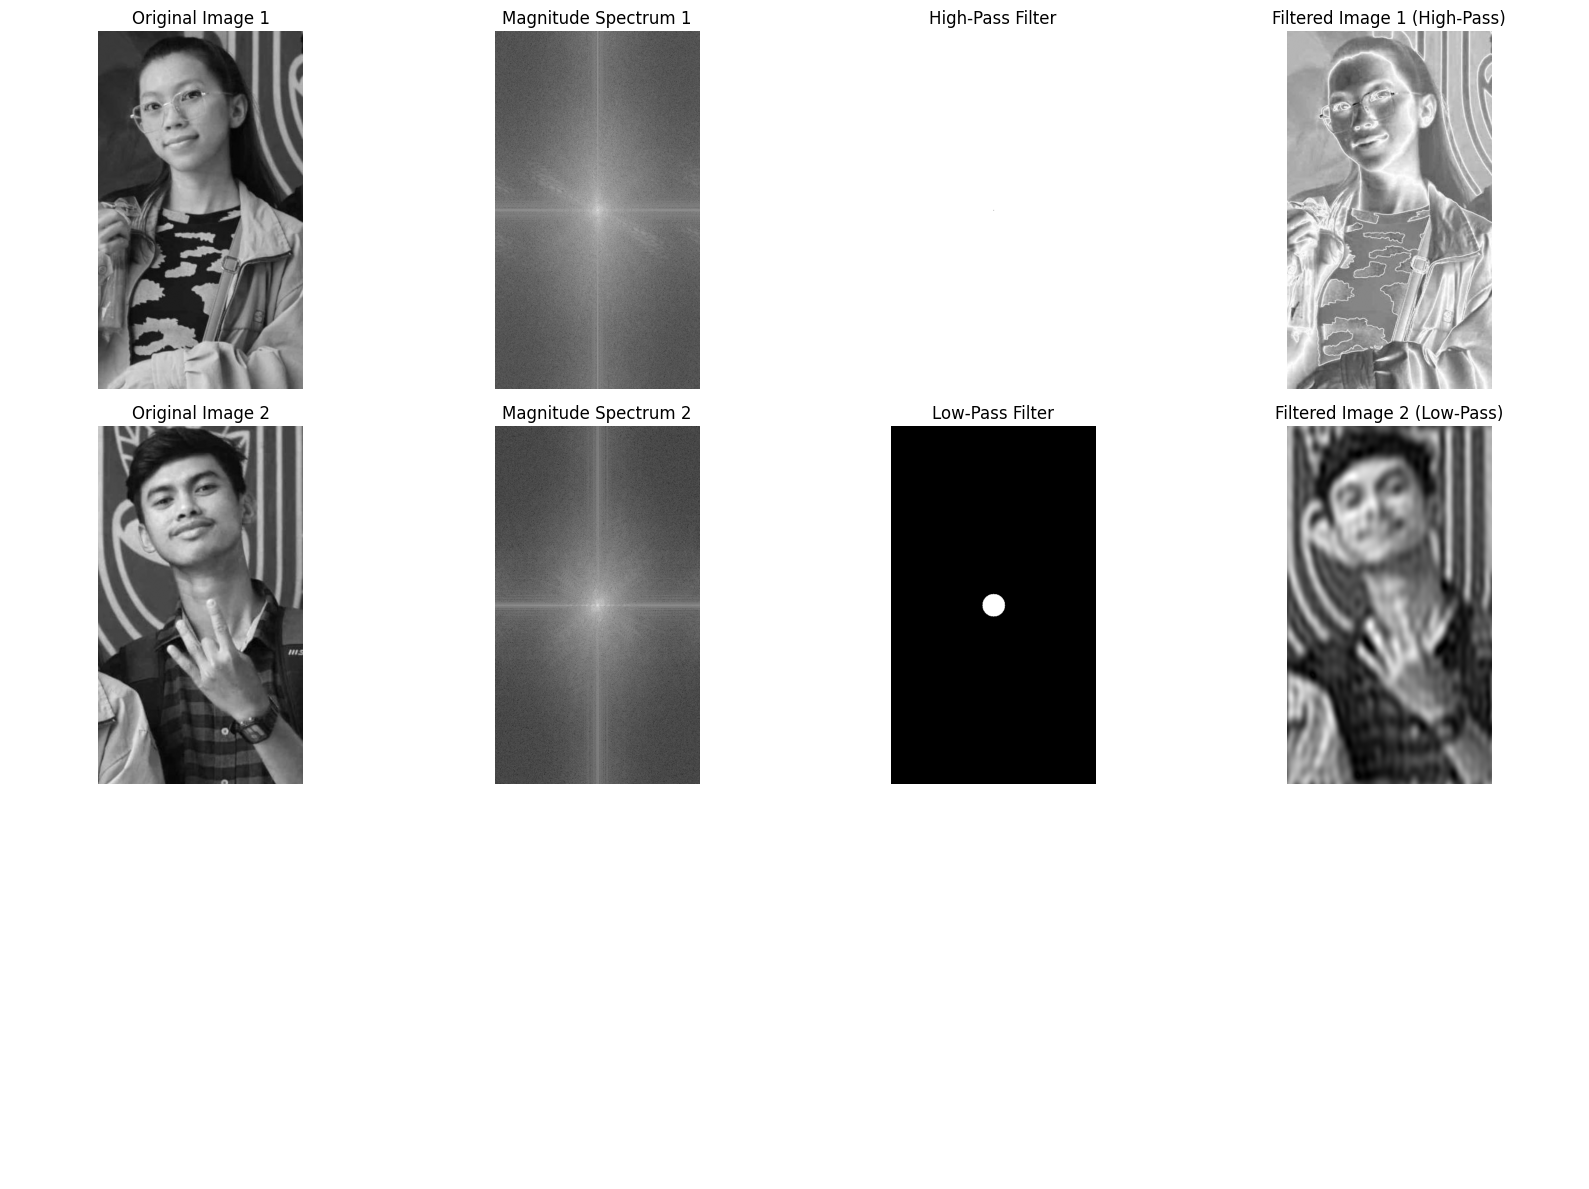

In [ ]:
magnitude_spectrum1 = 20 * np.log(np.abs(f_transform_shifted1) + 1e-10)
magnitude_spectrum2 = 20 * np.log(np.abs(f_transform_shifted2) + 1e-10)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Image 1
axes[0, 0].imshow(img1, cmap='gray')
axes[0, 0].set_title('Original Image 1')
axes[0, 0].axis('off')

axes[0, 1].imshow(magnitude_spectrum1, cmap='gray')
axes[0, 1].set_title('Magnitude Spectrum 1')
axes[0, 1].axis('off')

axes[0, 2].imshow(high_pass_filter1, cmap='gray')
axes[0, 2].set_title('High-Pass Filter')
axes[0, 2].axis('off')

axes[0, 3].imshow(filtered_img1, cmap='gray') # Changed cmap to gray_r
axes[0, 3].set_title('Filtered Image 1 (High-Pass)')
axes[0, 3].axis('off')

# Image 2
axes[1, 0].imshow(img2, cmap='gray')
axes[1, 0].set_title('Original Image 2')
axes[1, 0].axis('off')

axes[1, 1].imshow(magnitude_spectrum2, cmap='gray')
axes[1, 1].set_title('Magnitude Spectrum 2')
axes[1, 1].axis('off')

axes[1, 2].imshow(low_pass_filter2, cmap='gray')
axes[1, 2].set_title('Low-Pass Filter')
axes[1, 2].axis('off')

axes[1, 3].imshow(filtered_img2, cmap='gray')
axes[1, 3].set_title('Filtered Image 2 (Low-Pass)')
axes[1, 3].axis('off')

# Remove the unused subplots in the third row
for i in range(4):
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# filtered_img2 = np.flip(filtered_img2, axis=1)
# filtered_img2

In [ ]:
hybrid = (filtered_img1 + filtered_img2)/2

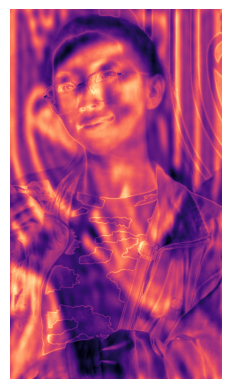

In [ ]:

plt.imshow(hybrid, cmap='magma')
# plt.title('Hybrid Image')
plt.axis('off')
plt.savefig('SrongNeth.png', dpi=1000)